In [1]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [2]:
aoi = {
    "type": "Polygon",
   
    "coordinates": [
        [
            [
              112.07070429065317,
              -7.036265783748036
            ],
            [
              112.19740799249746,
              -7.036224356301773
            ],
            [
              112.19740713316935,
              -7.101920167256907
            ],
            [
              112.07064606635191,
              -7.101920088468077
            ],
            [
              112.07070429065317,
              -7.036265783748036
            ]
        ]
    ]
}
s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 112.07064606635191,
        "south": -7.101920088468077,
        "east": 112.19740799249746,
        "north": -7.036224356301773
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["SO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_so2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_so2_aoi = s5p_so2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_so2_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_so2_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_so2")

0:00:00 Job 'j-2609121241074add8000576ed7d66a02': send 'start'


0:00:05 Job 'j-2609121241074add8000576ed7d66a02': queued (progress 0%)


0:00:10 Job 'j-2609121241074add8000576ed7d66a02': queued (progress 0%)


0:00:17 Job 'j-2609121241074add8000576ed7d66a02': queued (progress 0%)


0:00:25 Job 'j-2609121241074add8000576ed7d66a02': queued (progress 0%)


In [10]:
import pandas as pd

df = pd.read_csv("so2.csv")

# pastikan kolom tanggal valid
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ambil hanya bulan dan tahun
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

new_df = pd.DataFrame({
    "date": df['date'],
    "SO2": df['SO2']
})

new_df.to_csv("SO2_Timeseries.csv", index=False)

In [11]:
import pandas as pd

df = pd.read_csv("../../data/polutan/CO_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-31'], dtype='datetime64[ns]', freq='D')


In [12]:
import pandas as pd

df = pd.read_csv("../../data/polutan/SO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-31'], dtype='datetime64[ns]', freq='D')


In [13]:
import pandas as pd

df = pd.read_csv("../../data/polutan/NO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 1
Daftar tanggal missing:
DatetimeIndex(['2026-08-31'], dtype='datetime64[ns]', freq='D')


In [15]:
import pandas as pd

df_co = pd.read_csv("CO_Timeseries.csv")
df_no2 = pd.read_csv("NO2_Timeseries.csv")
df_so2 = pd.read_csv("SO2_Timeseries.csv")

dataframe_merged = pd.DataFrame({
    "date": df_co['date'],
    "CO": df_co['CO'],
    "NO2": df_no2['NO2'],
    "SO2": df_so2['SO2']
})

dataframe_merged.to_csv("Polutan_Widang.csv", index=False)

In [3]:
import pandas as pd
import numpy as np

# 1. Baca file time series
df = pd.read_csv("NO2_Timeseries.csv")

# 2. Hitung Kuartil dan IQR dari kolom NO2
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

# 3. Tentukan ambang batas outlier
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# 4. Ganti nilai outlier menjadi kosong (NaN)
# Menggunakan fungsi where: mempertahankan nilai yang di dalam batas, sisanya diubah ke np.nan
df['NO2'] = df['NO2'].where((df['NO2'] >= batas_bawah) & (df['NO2'] <= batas_atas), np.nan)

# 5. Simpan data ke CSV baru
df.to_csv("NO2_Outlier.csv", index=False)

Jumlah missing value sebelum: 158
Jumlah missing value setelah: 1


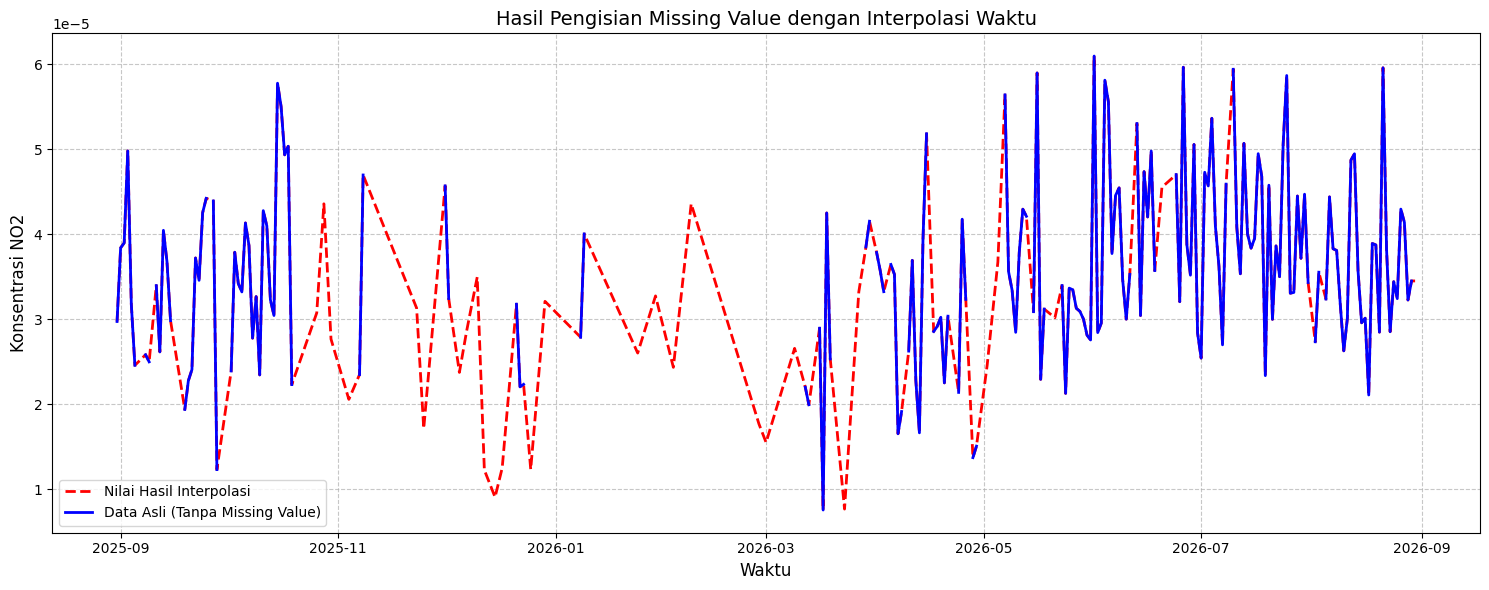

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Baca data yang memiliki missing value
df = pd.read_csv("../../data/polutan/NO2_Outlier.csv")

# 2. Persiapan kolom tanggal (sangat penting untuk urutan interpolasi)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by='date') # Sorting tanggal
    df = df.set_index('date')      # Jadikan tanggal sebagai indeks

# Cek jumlah data kosong sebelum diproses
print("Jumlah missing value sebelum:", df['NO2'].isna().sum())

# Simpan data asli untuk keperluan visualisasi (opsional)
df['NO2_Asli'] = df['NO2']

# 3. Mengisi missing value dengan Interpolasi
# Menggunakan method='time' karena data kita adalah time series dengan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# Cek jumlah data kosong setelah diproses
print("Jumlah missing value setelah:", df['NO2'].isna().sum())

# 4. Simpan data yang sudah bersih ke file baru
# Reset index agar kolom 'date' kembali menjadi kolom biasa saat disimpan
df[['NO2']].reset_index().to_csv("../../data/polutan/NO2_after.csv", index=False)


# --- VISUALISASI HASIL INTERPOLASI ---
plt.figure(figsize=(15, 6))

# Plot data hasil interpolasi (garis merah di bawah)
plt.plot(df.index, df['NO2'], color='red', label='Nilai Hasil Interpolasi', linestyle='--', linewidth=2)

# Plot data asli menimpa di atasnya (garis biru)
plt.plot(df.index, df['NO2_Asli'], color='blue', label='Data Asli (Tanpa Missing Value)', linewidth=2)

plt.title('Hasil Pengisian Missing Value dengan Interpolasi Waktu', fontsize=14)
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Konsentrasi NO2', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv("../../data/polutan/NO2_after.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_widang_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 1
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


In [9]:
import pandas as pd

# ---------- 1. Muat hasil ekstraksi TSFEL ----------
df_features = pd.read_csv("../../data/polutan/NO2_widang_TSFEL.csv")

# ---------- 2. Mapping resmi fitur -> domain (sesuai features.json TSFEL) ----------
FEATURE_DOMAIN_MAP = {
    # Statistical (21)
    "abs_energy": "statistical", "average_power": "statistical", "calc_max": "statistical",
    "calc_mean": "statistical", "calc_median": "statistical", "calc_min": "statistical",
    "calc_std": "statistical", "calc_var": "statistical", "ecdf": "statistical",
    "ecdf_percentile": "statistical", "ecdf_percentile_count": "statistical",
    "ecdf_slope": "statistical", "entropy": "statistical", "hist_mode": "statistical",
    "interq_range": "statistical", "kurtosis": "statistical", "mean_abs_deviation": "statistical",
    "median_abs_deviation": "statistical", "pk_pk_distance": "statistical", "rms": "statistical",
    "skewness": "statistical",

    # Temporal (15)
    "auc": "temporal", "autocorr": "temporal", "calc_centroid": "temporal",
    "distance": "temporal", "lempel_ziv": "temporal", "mean_abs_diff": "temporal",
    "mean_diff": "temporal", "median_abs_diff": "temporal", "median_diff": "temporal",
    "negative_turning": "temporal", "neighbourhood_peaks": "temporal",
    "positive_turning": "temporal", "slope": "temporal", "sum_abs_diff": "temporal",
    "zero_cross": "temporal",

    # Spectral (26)
    "fundamental_frequency": "spectral", "human_range_energy": "spectral", "lpcc": "spectral",
    "max_frequency": "spectral", "max_power_spectrum": "spectral", "median_frequency": "spectral",
    "mfcc": "spectral", "power_bandwidth": "spectral", "spectral_centroid": "spectral",
    "spectral_decrease": "spectral", "spectral_distance": "spectral", "spectral_entropy": "spectral",
    "spectral_kurtosis": "spectral", "spectral_positive_turning": "spectral",
    "spectral_roll_off": "spectral", "spectral_roll_on": "spectral", "spectral_skewness": "spectral",
    "spectral_slope": "spectral", "spectral_spread": "spectral", "spectral_variation": "spectral",
    "spectrogram_mean_coeff": "spectral", "wavelet_abs_mean": "spectral", "wavelet_energy": "spectral",
    "wavelet_entropy": "spectral", "wavelet_std": "spectral", "wavelet_var": "spectral",

    # Fractal (6) - domain terpisah di TSFEL
    "dfa": "fractal", "higuchi_fractal_dimension": "fractal", "hurst_exponent": "fractal",
    "maximum_fractal_length": "fractal", "mse": "fractal", "petrosian_fractal_dimension": "fractal",
}

# ---------- 3. Kelompokkan kolom sesuai domain ----------
domain_columns = {"statistical": [], "temporal": [], "spectral": [], "fractal": [], "unknown": []}
for col in df_features.columns:
    domain = FEATURE_DOMAIN_MAP.get(col, "unknown")
    domain_columns[domain].append(col)

for domain, cols in domain_columns.items():
    print(f"{domain.upper()} ({len(cols)}): {cols}")

# ---------- 4. (Opsional) Pisah jadi DataFrame terpisah per domain ----------
df_statistical = df_features[domain_columns["statistical"]]
df_temporal = df_features[domain_columns["temporal"]]
df_spectral = df_features[domain_columns["spectral"]]
df_fractal = df_features[domain_columns["fractal"]]

# ---------- 5. (Opsional) Simpan masing-masing sebagai CSV terpisah ----------
df_statistical.to_csv('NO2_fitur_statistical.csv', index=False)
df_temporal.to_csv('NO2_fitur_temporal.csv', index=False)
df_spectral.to_csv('NO2_fitur_spectral.csv', index=False)
df_fractal.to_csv('NO2_fitur_fractal.csv', index=False)

STATISTICAL (21): ['abs_energy', 'average_power', 'calc_max', 'calc_mean', 'calc_median', 'calc_min', 'calc_std', 'calc_var', 'ecdf', 'ecdf_percentile', 'ecdf_percentile_count', 'ecdf_slope', 'entropy', 'hist_mode', 'interq_range', 'kurtosis', 'mean_abs_deviation', 'median_abs_deviation', 'pk_pk_distance', 'rms', 'skewness']
TEMPORAL (15): ['auc', 'autocorr', 'calc_centroid', 'distance', 'lempel_ziv', 'mean_abs_diff', 'mean_diff', 'median_abs_diff', 'median_diff', 'negative_turning', 'neighbourhood_peaks', 'positive_turning', 'slope', 'sum_abs_diff', 'zero_cross']
SPECTRAL (26): ['fundamental_frequency', 'human_range_energy', 'lpcc', 'max_frequency', 'max_power_spectrum', 'median_frequency', 'mfcc', 'power_bandwidth', 'spectral_centroid', 'spectral_decrease', 'spectral_distance', 'spectral_entropy', 'spectral_kurtosis', 'spectral_positive_turning', 'spectral_roll_off', 'spectral_roll_on', 'spectral_skewness', 'spectral_slope', 'spectral_spread', 'spectral_variation', 'spectrogram_mean_